In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [14]:
df = pd.read_csv("diabetes_cleaned.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (229781, 22)
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.

In [15]:
features = [
    "BMI",
    "HighBP",
    "HighChol",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Income"
]

X = df[features]

print("\nFeatures Used for Clustering:")
print(features)

print("\nFeature Data:")
print(X.head())


Features Used for Clustering:
['BMI', 'HighBP', 'HighChol', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Income']

Feature Data:
    BMI  HighBP  HighChol  GenHlth  MentHlth  PhysHlth   Age  Income
0  40.0     1.0       1.0      5.0      18.0      15.0   9.0     3.0
1  25.0     0.0       0.0      3.0       0.0       0.0   7.0     1.0
2  28.0     1.0       1.0      5.0      30.0      30.0   9.0     8.0
3  27.0     1.0       0.0      2.0       0.0       0.0  11.0     6.0
4  24.0     1.0       1.0      2.0       3.0       0.0  11.0     4.0


In [16]:
print("\nMissing Values:")
print(X.isnull().sum())


Missing Values:
BMI         0
HighBP      0
HighChol    0
GenHlth     0
MentHlth    0
PhysHlth    0
Age         0
Income      0
dtype: int64


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled Data:")
print(X_scaled[:5])


Scaled Data:
[[ 1.6672198   1.09567501  1.12413247  2.25311122  1.87907388  1.14129968
   0.29524111 -1.38132379]
 [-0.54310088 -0.91267939 -0.88957488  0.37461791 -0.45443416 -0.51679134
  -0.35121265 -2.33713069]
 [-0.10103675  1.09567501  1.12413247  2.25311122  3.43474592  2.79939071
   0.29524111  1.00819343]
 [-0.24839146  1.09567501 -0.88957488 -0.56462875 -0.45443416 -0.51679134
   0.94169487  0.05238654]
 [-0.69045559  1.09567501  1.12413247 -0.56462875 -0.06551616 -0.51679134
   0.94169487 -0.90342035]]


In [18]:
inertia = []
K_range = range(2, 9)
for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


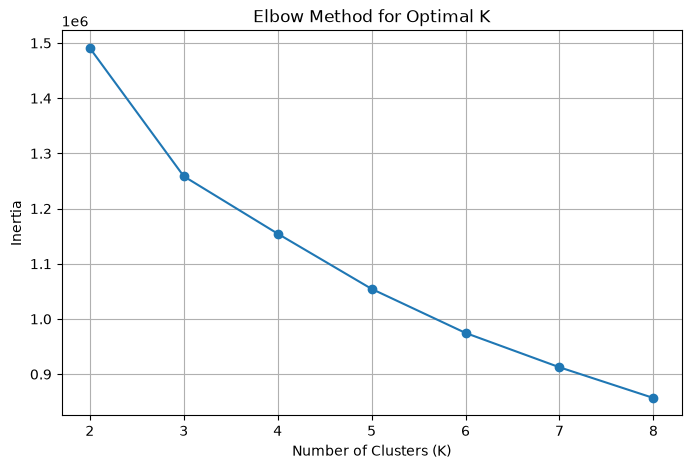

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.grid(True)
plt.show()


In [20]:
silhouette_scores = []
for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=5000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.1979
K = 3, Silhouette Score = 0.1994
K = 4, Silhouette Score = 0.1809
K = 5, Silhouette Score = 0.1925
K = 6, Silhouette Score = 0.2165
K = 7, Silhouette Score = 0.2013
K = 8, Silhouette Score = 0.2053


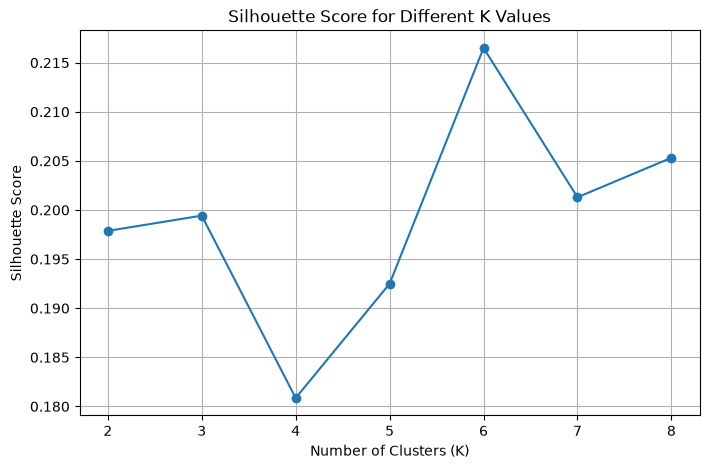

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.grid(True)
plt.show()

In [23]:
best_k = K_range[
    np.argmax(silhouette_scores)
]
print("\nBest K:", best_k)


Best K: 6


In [24]:
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

In [25]:
df["Cluster"] = cluster_labels
print("\nDataset with Cluster Labels:")
print(df.head())



Dataset with Cluster Labels:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  NoDocbcCost  GenHlth  \
0                   0.0           0.0     0.0  ...          0.0      5.0   
1                   0.0           1.0     0.0  ...          1.0      3.0   
2                   0.0           0.0     1.0  ...          1.0      5.0   
3                   0.0           1.0     1.0  ...          0.0      2.0   
4                   0.0           1.0     1.0  ...          0.0      2.0   

   MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  Income  Cluster  
0      18.0      15

In [26]:
cluster_counts = df["Cluster"].value_counts().sort_index()
print("\nCluster Sizes:")
print(cluster_counts)


Cluster Sizes:
Cluster
0    17614
1    35126
2    33338
3    20476
4    46833
5    76394
Name: count, dtype: int64


In [27]:
cluster_profile = df.groupby("Cluster")[features].mean()
print("\nCluster Profiles:")
print(cluster_profile)


Cluster Profiles:
               BMI    HighBP  HighChol   GenHlth   MentHlth   PhysHlth  \
Cluster                                                                  
0        30.524980  0.542920  0.537470  3.611843  27.071250  14.600602   
1        30.125776  0.978734  0.000000  2.538832   1.150088   1.485025   
2        27.724969  0.000210  1.000000  2.289100   1.449997   1.464185   
3        30.429137  0.657941  0.579703  3.989598   3.050010  26.142264   
4        29.794717  0.998954  1.000000  2.703372   1.216663   1.687208   
5        26.871469  0.002841  0.000000  2.098136   1.576891   1.332696   

              Age    Income  
Cluster                      
0        7.475361  4.466163  
1        8.919746  5.948756  
2        8.182344  6.448467  
3        9.341375  4.567249  
4        9.630175  5.859245  
5        6.520015  6.322106  


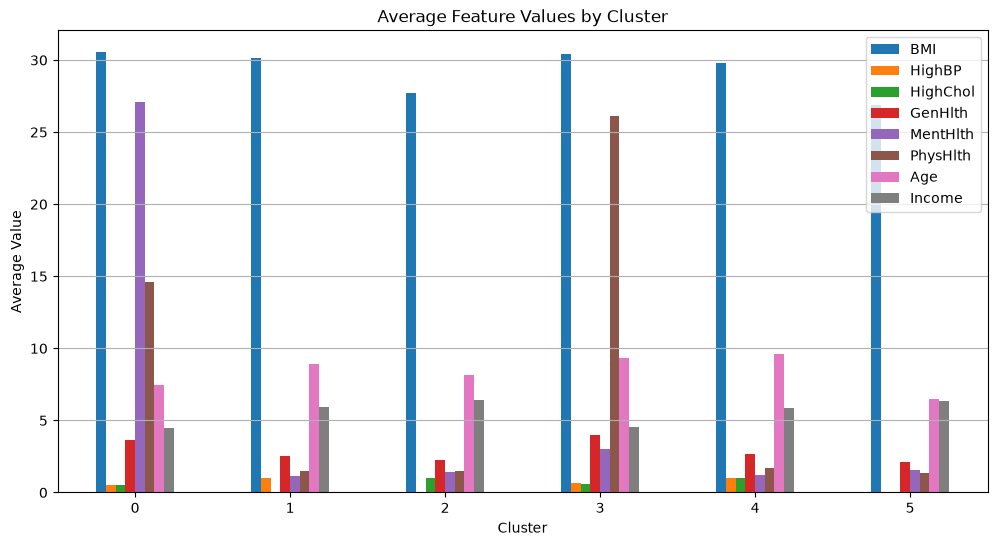

In [28]:
cluster_profile.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Average Feature Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [29]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)


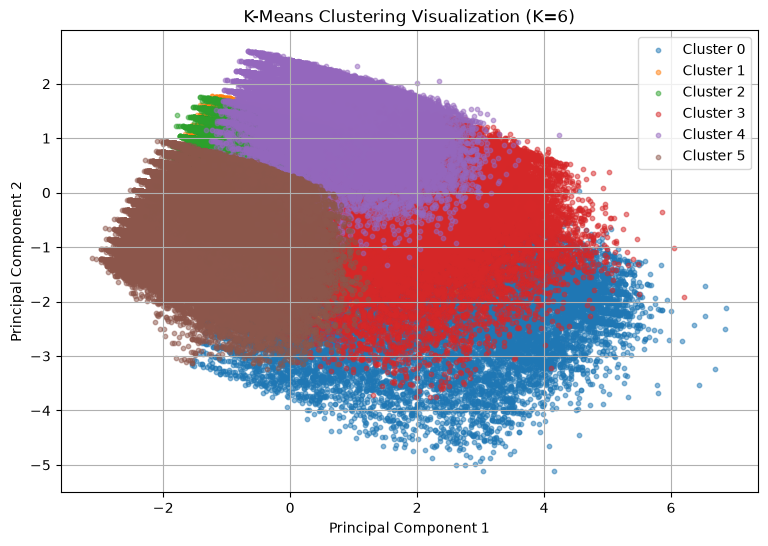

In [30]:
plt.figure(figsize=(9, 6))
for cluster in sorted(df["Cluster"].unique()):

    mask = df["Cluster"] == cluster

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=10,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    f"K-Means Clustering Visualization (K={best_k})"
)
plt.legend()
plt.grid(True)
plt.show()

In [31]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels,
    sample_size=5000,
    random_state=42
)

print(
    "\nFinal Silhouette Score:",
    round(final_silhouette, 4)
)


Final Silhouette Score: 0.2165


In [32]:
for cluster in sorted(df["Cluster"].unique()):

    
    print(f"CLUSTER {cluster}")
    cluster_data = df[
        df["Cluster"] == cluster
    ]

    print(
        "Number of People:",
        len(cluster_data)
    )

    print("\nAverage Characteristics:")

    print(
        cluster_data[features].mean().round(2)
    )


CLUSTER 0
Number of People: 17614

Average Characteristics:
BMI         30.52
HighBP       0.54
HighChol     0.54
GenHlth      3.61
MentHlth    27.07
PhysHlth    14.60
Age          7.48
Income       4.47
dtype: float64
CLUSTER 1
Number of People: 35126

Average Characteristics:
BMI         30.13
HighBP       0.98
HighChol     0.00
GenHlth      2.54
MentHlth     1.15
PhysHlth     1.49
Age          8.92
Income       5.95
dtype: float64
CLUSTER 2
Number of People: 33338

Average Characteristics:
BMI         27.72
HighBP       0.00
HighChol     1.00
GenHlth      2.29
MentHlth     1.45
PhysHlth     1.46
Age          8.18
Income       6.45
dtype: float64
CLUSTER 3
Number of People: 20476

Average Characteristics:
BMI         30.43
HighBP       0.66
HighChol     0.58
GenHlth      3.99
MentHlth     3.05
PhysHlth    26.14
Age          9.34
Income       4.57
dtype: float64
CLUSTER 4
Number of People: 46833

Average Characteristics:
BMI         29.79
HighBP       1.00
HighChol     1.00
GenHlth   

In [33]:
df.to_csv(
    "diabetes_clustered.csv",
    index=False
)

print(
    "\nClustered dataset saved as "
    "'diabetes_clustered.csv'"
)


Clustered dataset saved as 'diabetes_clustered.csv'
